# Create video with fly on ball, brain activity, and fly behavior 

## Imports

In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis
from gulp2p.preproc import utils as utils
from gulp2p.preproc import imaging
from gulp2p.preproc import rois
from gulp2p.preproc.tiff import Tiff

from moviepy.editor import VideoClip, VideoFileClip, clips_array, CompositeVideoClip, TextClip
from moviepy.video.fx.resize import resize
from moviepy.video.io.bindings import mplfig_to_npimage

## Load data

### Files:

In [2]:
# fictrac_video_path = Path(r"Z:\Live Fly Imaging data\fictrac\fictrac-dbg-20240103_102052.avi")
# fictrac_video_path = Path(r"Z:\Live Fly Imaging data\fictrac\fictrac-dbg-20240110_113229.avi")
fictrac_video_path = Path(r"Z:\Live Fly Imaging data\fictrac\fictrac-dbg-20240110_113229_copy.avi")
# fictrac_video_path = Path(r"Z:\Live Fly Imaging data\fictrac\fictrac-raw-20240103_111219.avi")
tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20231207\20231207_DR019xiGluSnFr_Fly1_00001.tif")
synced_bhv_img_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20231207\20231207_DR019xiGluSnFr_Fly1_00001.p")


### Read behavioral file

In [3]:
with open(synced_bhv_img_path, 'rb') as pkl:
    exptDat = pickle.load(pkl)
expDf = exptDat['expDf']

In [4]:
print(expDf.keys())

Index(['roi0', 'roi1', 'roi2', 'roi3', 'roi4', 'roi5', 'roi6', 'roi7', 'roi8',
       'roi9', 'roi10', 'roi11', 'roi12', 'roi13', 'roi14', 'posTime', 'frame',
       'x', 'y', 'angle', 'vT', 'vR', 'vTfilt', 'vRfilt', 's', 'ds', 'dx',
       'dy', 'flight', 'clipped'],
      dtype='object')


### Read Tiff:

In [6]:
# Load tiff
tiff = Tiff(tiff_path)
tiff.metadata
zaxis = 1
mip_stack = np.squeeze(np.max(tiff.stack, axis=zaxis))
print(tiff.metadata)

{'laser_power': 0.35, 'SizeC': 1, 'discard_fb_frames': True, 'flyback_time': 0.001, 'num_fb_frames': 1, 'SizeY': 256, 'SizeX': 128, 'frame_interval': 0.017176, 'frame_rate': 58.2206, 'volume_rate': 6.46896, 'zoom_factor': 2.9, 'pixel_bin_factor': 1, 'SizeZ': 9, 'SizeT': 2350, 'date': datetime.datetime(2023, 12, 7, 9, 52, 39, 385401), 'file_size': 1436527630, 'dimension_order': 'TZCYX', 'pixel_width': 2.11512227715946, 'width_unit': 'um', 'pixel_height': 2.11512227715946, 'height_unit': 'um'}


## Plot using MoviePy

### Functions

In [7]:
def show_frame(animation, time=1):
    ax = plt.subplot()
    ax.imshow(animation.get_frame(time))
    ax.set_axis_off()

In [8]:
def grayscale_to_rgb_frame(frame, cmap='viridis'):
    cm = plt.get_cmap(cmap)
    rgb_frame = cm(frame)
    # Cut off alpha channel
    rgb_frame = rgb_frame[:,:,:3] * 255
    return rgb_frame.astype(int)

def get_tiff_frame_at_time(tiff, time, convert_to_rbg=False, motion_correct=True):
    tiff_frame_idx = round(time * tiff.metadata['volume_rate'])
    tiff_vol_count = tiff.metadata['SizeT']
    if tiff_frame_idx > tiff_vol_count:
        tiff_frame_idx = tiff_vol_count - 1
    mip_stack = tiff.get_mip_stack(motion_correct)
    
    frame = mip_stack[tiff_frame_idx]
    if convert_to_rbg:
        frame = grayscale_to_rgb_frame(frame)
    return frame

def make_tiff_frame_creator(tiff, motion_correct=True):
    def make_tiff_frame(time):
        # Given a timepoint return the frame at that time.
        frame = get_tiff_frame_at_time(tiff, time, convert_to_rbg=True, motion_correct=motion_correct)
        return frame
    return make_tiff_frame

In [9]:
# def make_frame_matplotlib(time, ax):
#     ax.clear()
#     frame = get_frame_at_time(tiff, time, convert_to_rbg=False)
#     ax.imshow(frame, interpolation='none', cmap='viridis')
#     ax.set_axis_off()
#     return mplfig_to_npimage(fig)

plt.style.use('dark_background')

def get_frame_near_time(time_series, time):
    return time_series.sub(time).abs().idxmin()

def make_hdpov_frame_creator(size_px, style="hdvtime", ):
    # Used to make frame creater showing fly's head direction as vertical line matching its hd. 
    # convert size to inches for matplot
    px = 1/plt.rcParams['figure.dpi']  # inches per pixel
    size = (size_px[0]*px, size_px[1]*px)
    left = 0.01
    right = 0.01
    top = 0.2
    bottom = 0.35
    fig = plt.figure(figsize=size, layout="constrained")
    ax = fig.add_subplot()
    ax.tick_params(direction='in')

    # hdvtime params
    time_window = 5 # seconds

    # Shift range of angles to center on 0
    expDf['centered_angle'] = np.where(expDf['angle']>180, expDf['angle']-360, expDf['angle'])

    def make_hdpov_frame(time):
        # https://codereview.stackexchange.com/questions/204549/lookup-closest-value-in-pandas-dataframe
        cur_frame_idx = get_frame_near_time(expDf['posTime'], time)
        head_direction = expDf['centered_angle'].iloc[cur_frame_idx]
        if style == "pov":
            ax.axvline(head_direction)
            ax.set_xticks(range(0,360+1,90))
            ax.set_xlim([0, 360])
        if style == "hdvtime":
            # Plot head direction vs time
            old_frame_idx = get_frame_near_time(expDf['posTime'], time-5)
            ax.plot(expDf['posTime'].iloc[cur_frame_idx],
                    expDf['centered_angle'].iloc[cur_frame_idx],
                    marker='o',
                    markersize=1,
                    linestyle='none',
                    color='C0')
            min_time = max(0, time-5)
            max_time = max(5, time)
            ax.set_xlim([min_time, max_time])
            ax.set_ylim([-180,180])
            ax.set_yticks(range(-180, 180+1, 180))
            ax.set_xlabel("time")
            ax.set_title("head direction (deg)",fontsize=9)

        image = mplfig_to_npimage(fig)
        plt.close(fig)
        return image
    return make_hdpov_frame

def make_fly_path_frame_creator(size_px):
    # convert size to inches for matplot
    px = 1/plt.rcParams['figure.dpi']  # inches per pixel
    size = (size_px[0]*px, size_px[1]*px)
    left = 0.01
    right = 0.01
    top = 0.2
    bottom = 0.35
    fig = plt.figure(figsize=size, layout="constrained")
    ax = fig.add_subplot()

    ax.set_aspect('equal')
    ax.tick_params(direction='in')

    time_window = 5 # seconds
    
    def make_fly_path_frame(time):
        cur_frame_idx = get_frame_near_time(expDf['posTime'], time)
        old_frame_idx = get_frame_near_time(expDf['posTime'], time-5)
        ax.plot(expDf['x'].iloc[cur_frame_idx-1:cur_frame_idx+1],
                expDf['y'].iloc[cur_frame_idx-1:cur_frame_idx+1],
                marker='none',
                # markersize=1,
                linestyle='-',
                color='C0')
        image = mplfig_to_npimage(fig)
        plt.close(fig)
        return image
    return make_fly_path_frame


### Create video clips

#### Parameters

In [10]:
duration = 10 # seconds
fps = 60 # Frames per second
is_video_exists = False

#### Fictrac

In [11]:
fictrac_video_midline = 318 # Pixels

fictrac_animation = (VideoFileClip(fictrac_video_path.as_posix())
                     .subclip(0,duration)
                     .crop(x1=0, x2=fictrac_video_midline)
                     .margin(left=10))

#### Tiff

In [12]:
# Create video
make_tiff_frame = make_tiff_frame_creator(tiff, motion_correct=True)
tiff_animation = (VideoClip(make_tiff_frame)
                  .resize(height=fictrac_animation.size[1]))

#### Head Direction

In [13]:
if is_video_exists:
    width=fictrac_animation.size[0]-10
    height = 100
else:
    width = tiff_animation.size[0]
    height = 100
make_hd_frame = make_hdpov_frame_creator(size_px=(width, height),
                                         style="hdvtime")
head_direction_animation = (VideoClip(make_hd_frame)
                            .margin(bottom=5, left=10))

#### Fly Path

In [14]:
# Plot fly path if there is no fictrac video
if is_video_exists:
    width=fictrac_animation.size[0]-10
    height = 150
else:
    width = tiff_animation.size[0]
    height = tiff_animation.size[1]-100
make_fly_path_frame = make_fly_path_frame_creator(size_px=(width, height))
fly_path_animation = (VideoClip(make_fly_path_frame))

#### Stimuli

In [15]:
# Get unityvr object
# Figure out type of stimuli
# Display stimuli

#### Text

In [16]:
# Add text
date, line, fly, trial = tiff.path.name.split(".")[0].split("_")
text = f"{date} {line}\n{fly}_{trial}" # Split name into 2 lines
txt_clip = (TextClip(txt = text, fontsize = 12, color = 'white')
            .set_duration(duration))

### Assemble list of clips

In [17]:
if is_video_exists:
    composite_size = (tiff_animation.size[0] + fictrac_animation.size[0],
                    max(tiff_animation.size[1], fictrac_animation.size[1]) + head_direction_animation.size[1])

    midleft = tiff_animation.size[0]/2 - txt_clip.size[0]/2
    midtop = head_direction_animation.size[1]/2 - txt_clip.size[1]/2

    composite_video = CompositeVideoClip([tiff_animation.set_position(('left','bottom')),
                                        txt_clip.set_position((midleft, midtop)),
                                        fictrac_animation.set_position(('right','bottom')),
                                        head_direction_animation.set_position(('right','top')),
                                        fly_path_animation.set_position(('right','bottom'))],
                                        size=composite_size)
    composite_video = composite_video.subclip(0, duration)
else:
    composite_size = (tiff_animation.size[0]*2,
                      tiff_animation.size[1] + head_direction_animation.size[1])

    midleft = tiff_animation.size[0]/2 - txt_clip.size[0]/2
    midtop = head_direction_animation.size[1]/2 - txt_clip.size[1]/2

    composite_video = CompositeVideoClip([tiff_animation.set_position(('left','bottom')),
                                        txt_clip.set_position((midleft, midtop)),
                                        head_direction_animation.set_position(('right','top')),
                                        fly_path_animation.set_position(('right','bottom'))],
                                        size=composite_size)
    composite_video = composite_video.subclip(0, duration)

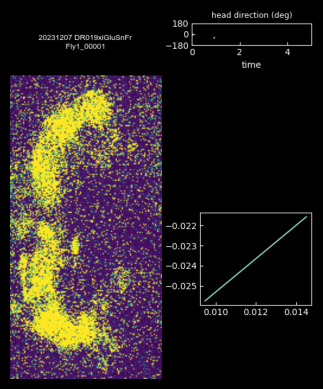

In [18]:
show_frame(composite_video)

In [19]:
output = Path(f"../results/videos/{tiff_path.stem}.mp4").as_posix()
composite_video.write_videofile(output, fps=fps)
composite_video.close()
fictrac_animation.close()

Moviepy - Building video ../results/videos/20231207_DR019xiGluSnFr_Fly1_00001.mp4.
Moviepy - Writing video ../results/videos/20231207_DR019xiGluSnFr_Fly1_00001.mp4



t:   0%|          | 0/600 [00:00<?, ?it/s, now=None]

t:  11%|█         | 64/600 [00:03<00:34, 15.46it/s, now=None]

In [ ]:
tiff_animation.size

(240, 480)

In [ ]:
fictrac_animation.size

(328, 480)

In [ ]:
composite_video.size

(480, 585)

In [ ]:
# ## Try clipsarray
# clips_array_animation = clips_array([[head_direction_animation, head_direction_animation],
#                                      [tiff_animation, fictrac_animation]]).set_duration(10)

# show_frame(clips_array_animation)

In [ ]:
# clips_array_animation.write_videofile(output, fps=fps)

In [3]:
from gulp2p.viz.video import create_video
output_path = Path(r"C:\Users\ahshenas\Documents\GitHub\GULP\results\videos\testvideo.mp4")
create_video(output_path, tiff_path, synced_bhv_img_path, fictrac_video_path)

Moviepy - Building video C:/Users/ahshenas/Documents/GitHub/GULP/results/videos/testvideo.mp4.
Moviepy - Writing video C:/Users/ahshenas/Documents/GitHub/GULP/results/videos/testvideo.mp4



Moviepy - Done !
Moviepy - video ready C:/Users/ahshenas/Documents/GitHub/GULP/results/videos/testvideo.mp4
